<h1><font color ="Blue"><center> GIS Applications in Engineering</h1>

<h2><font color ="Red"><center> Shaseevarajan Sivanantharajah</h1>

<h3><font color ="Black"><center> Assignment 5</h1>

**Problem Statement**
1. Take lat-long for El Paso, San Antonio, Austin, Dallas, Houston and Beaumont in a CSV file and create a pandas Geodataframe using the Shapely Point Object.
2. Create two line strings - 1) Line Connecting El Paso, San Antonio, Houston and Beaumont (This is approximately I-10) 2) Create a line connecting Austin and San Antonio (this is I-35 approiximately)
3. Use the linestrings to create a line geodataframe
4. Create a Polygon connecting San Antonio, Austin, Dallas, Houston (use San Antonio to close the loop). This is the Texas Triangle Create a Geopandas Geodataframe
5. Compute the area of the Texas Triangle in sq. miles
6. Compute Approximately the number of People who live within the Texas Triangle.

In [67]:
import os
import pandas as pd
import geopandas as gpd
from shapely import Point,LineString,Polygon
from matplotlib import pyplot as plt
import numpy as np

In [47]:
path = "/home/harris/Downloads/Shasee/Assignment5"
os.chdir(path)

In [48]:
# City coordinates
data = {
    "City": ["El Paso", "San Antonio", "Austin", "Dallas", "Houston", "Beaumont", "Fort Worth"],
    "Latitude": [31.7619, 29.4241, 30.2672, 32.7767, 29.7604, 30.0802, 	32.7688],
    "Longitude": [-106.4850, -98.4936, -97.7431, -96.7970, -95.3698, -94.1266, 	-97.3093]
}

# Create DataFrame
df = pd.DataFrame(data)

# Save to CSV
df.to_csv("TXcities.csv", index=False)

In [49]:
fname = ('TXcities.csv')
a = pd.read_csv(fname)

In [50]:
a.head()

,City,Latitude,Longitude
0,El Paso,31.7619,-106.4850
1,San Antonio,29.4241,-98.4936
2,Austin,30.2672,-97.7431
3,Dallas,32.7767,-96.7970
4,Houston,29.7604,-95.3698


In [51]:
#Convert to a dictionary
#Zip function is used to iterate over multiple objects
#Dict is used to define the dictionary object
TXcities = dict(zip(a['City'],zip(a['Longitude'],a['Latitude'])))
TXcities

{'El Paso': (-106.485, 31.7619),
 'San Antonio': (-98.4936, 29.4241),
 'Austin': (-97.7431, 30.2672),
 'Dallas': (-96.797, 32.7767),
 'Houston': (-95.3698, 29.7604),
 'Beaumont': (-94.1266, 30.0802),
 'Fort Worth': (-97.3093, 32.7688)}

In [52]:
#Use the Point object of Shapely to create a set of Points
#Iterate over the dictionary to obtain the lat-long
geom = [Point(coord) for coord in TXcities.values()]
geom

[<POINT (-106.485 31.762)>,
 <POINT (-98.494 29.424)>,
 <POINT (-97.743 30.267)>,
 <POINT (-96.797 32.777)>,
 <POINT (-95.37 29.76)>,
 <POINT (-94.127 30.08)>,
 <POINT (-97.309 32.769)>]

In [53]:
# Create a Geopandas Data Frame
TXcitiesgpd = gpd.GeoDataFrame({"City":list(TXcities.keys())},geometry=geom,crs='EPSG:4326')
TXcitiesgpd.head()

,City,geometry
0,El Paso,POINT (-106.485 31.7619)
1,San Antonio,POINT (-98.4936 29.4241)
2,Austin,POINT (-97.7431 30.2672)
3,Dallas,POINT (-96.797 32.7767)
4,Houston,POINT (-95.3698 29.7604)


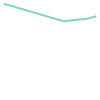

In [54]:
#Create LineSrings for Approx I10 and approx I35
roadI10 = LineString([TXcities['El Paso'],TXcities['San Antonio'],TXcities['Houston'],TXcities['Beaumont']])
roadI10

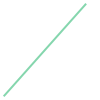

In [55]:
roadI35 = LineString([TXcities['Austin'],TXcities['San Antonio']])
roadI35

In [56]:
roads = gpd.GeoDataFrame({"HWY":["I10Approx","I35ApproxASA"]}, geometry= [roadI10,roadI35],crs='EPSG:4326')
roads.head()

,HWY,geometry
0,I10Approx,"LINESTRING (-106.485 31.7619, -98.4936 29.4241..."
1,I35ApproxASA,"LINESTRING (-97.7431 30.2672, -98.4936 29.4241)"


In [57]:
fname1 = "County_Boundaries.shp"
txbnd = gpd.read_file(fname1)
txgcs = txbnd.to_crs('EPSG:4326')
txgcsd = txgcs.dissolve().geometry.exterior


<function matplotlib.pyplot.show(close=None, block=None)>

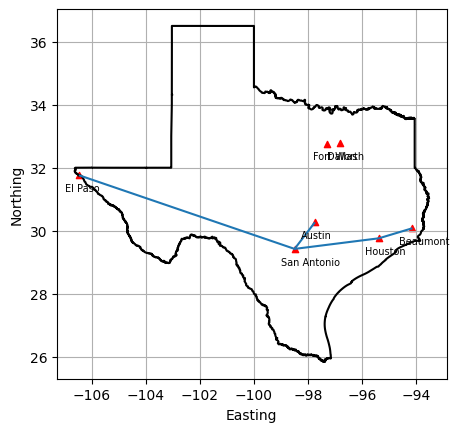

In [58]:
ax = txgcsd.plot(edgecolor = 'black', facecolor = 'none')
roads.plot(ax=ax)
TXcitiesgpd.plot(ax=ax,marker = '^',color='red', markersize=20)
for x, y, label in zip(TXcitiesgpd.geometry.x, TXcitiesgpd.geometry.y, TXcitiesgpd['City']):
    ax.text(x - 0.5, y - 0.5, label, fontsize=7, color='black')
plt.grid()
plt.xlabel('Easting')
plt.ylabel('Northing')
plt.show

<h6> Create a Texas Triangle Polygon</h6>


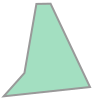

In [59]:
TXtriangle = Polygon([TXcities['San Antonio'],TXcities['Austin'],TXcities['Fort Worth'],TXcities['Dallas'], TXcities['Houston'], TXcities['San Antonio']])
TXtriangle

<function matplotlib.pyplot.show(close=None, block=None)>

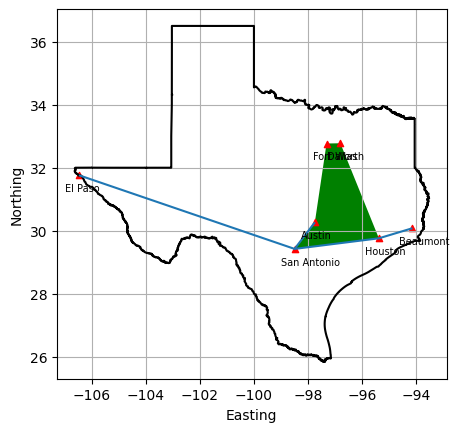

In [60]:
ax = txgcsd.plot(edgecolor = 'black', facecolor = 'none')
roads.plot(ax=ax)
TXtrianglegpd.plot (ax = ax, color ='green')
TXcitiesgpd.plot(ax=ax,marker = '^',color='red', markersize=20)
for x, y, label in zip(TXcitiesgpd.geometry.x, TXcitiesgpd.geometry.y, TXcitiesgpd['City']):
    ax.text(x - 0.5, y - 0.5, label, fontsize=7, color='black')
plt.grid()
plt.xlabel('Easting')
plt.ylabel('Northing')
plt.show

In [61]:
#For Polygon we need a list for all
zz = {'Name':['WonkyT']}
TXtrianglegpd = gpd.GeoDataFrame(zz,geometry=[TXtriangle], crs = 'EPSG:4326')
TXtaea = TXtrianglegpd.to_crs('EPSG:5070')

In [62]:
TXtaea['Area'] = TXtaea.area*3.861E-07
TXtaea.head()

,Name,geometry,Area
0,WonkyT,"POLYGON ((-241988.092 708683.246, -167451.371 ...",20732.678033


In [63]:
TXtaea.to_file('TXtaea.gpkg', driver = 'GPKG', layer = "Triangle") 

In [64]:
TXfracA = TXtaea.Area*100/268596 #Fraction of Area with Texas
TXfracA 

0    7.718908
Name: Area, dtype: float64

In [75]:
Txpop = gpd.read_file("TXTotal.gpkg")
Txpop.head()

,CMPTRL_CNT,DPS_CNTY_N,FIPS_ST_CN,TXDOT_CNTY,TXDOT_DIST,CNTY_NM,CNTY_NBR,DIST_NBR,GID,FIPS,county,census_2020_count,july1_2023_pop_est,jan1_2024_pop_est,num_chg_20_23,num_chg_20_24,pct_chg_20_23,pct_chg_20_24,FIPS_NEW,geometry
0,232,232,48463,232,15,Uvalde,232,15,35,463,Uvalde,24564,24758,24827,194,263,0.8,1.1,48463,"MULTIPOLYGON (((-11076323.62072 3386738.49202,..."
1,143,143,48285,143,13,Lavaca,143,13,36,285,Lavaca,20337,20274,20113,-63,-224,-0.3,-1.1,48285,"MULTIPOLYGON (((-10783021.18325 3456095.20958,..."
2,20,20,48039,20,12,Brazoria,20,12,37,39,Brazoria,372031,394817,398361,22786,26330,6.1,7.1,48039,"MULTIPOLYGON (((-10606980.49522 3451945.26248,..."
3,241,241,48481,241,13,Wharton,241,13,38,481,Wharton,41570,41700,41711,130,141,0.3,0.3,48481,"MULTIPOLYGON (((-10706181.77219 3456563.94224,..."
4,163,163,48325,163,15,Medina,163,15,39,325,Medina,50748,54889,56338,4141,5590,8.2,11,48325,"MULTIPOLYGON (((-11066621.01165 3397753.0156, ..."


In [76]:
Totpop = np.sum(pd.to_numeric(Txpop.jan1_2024_pop_est))
Totpop

30749924

In [77]:
TXcntpop = gpd.read_file("Assignment5.gpkg")
TXcntpop.head()

,CMPTRL_CNT,DPS_CNTY_N,FIPS_ST_CN,TXDOT_CNTY,TXDOT_DIST,CNTY_NM,CNTY_NBR,DIST_NBR,GID,FIPS,...,july1_2023_pop_est,jan1_2024_pop_est,num_chg_20_23,num_chg_20_24,pct_chg_20_23,pct_chg_20_24,FIPS_NEW,Name,Area,geometry
0,143,143,48285,143,13,Lavaca,143,13,36,285,...,20274,20113,-63,-224,-0.3,-1.1,48285,WonkyT,20732.678033,"MULTIPOLYGON (((-10783021.18325 3456095.20958,..."
1,15,15,48029,15,15,Bexar,15,15,41,29,...,2087996,2104986,78672,95662,3.9,4.8,48029,WonkyT,20732.678033,"MULTIPOLYGON (((-10982583.68176 3401191.93622,..."
2,89,89,48177,90,13,Gonzales,90,13,42,177,...,19580,19488,-73,-165,-0.4,-0.8,48177,WonkyT,20732.678033,"MULTIPOLYGON (((-10813945.74544 3455832.67556,..."
3,79,79,48157,80,12,Fort Bend,80,12,43,157,...,898514,911893,75735,89114,9.2,10.8,48157,WonkyT,20732.678033,"MULTIPOLYGON (((-10662623.55826 3473377.79134,..."
4,94,94,48187,95,15,Guadalupe,95,15,44,187,...,189430,193158,16724,20452,9.7,11.8,48187,WonkyT,20732.678033,"MULTIPOLYGON (((-10895403.80455 3485319.73886,..."


In [78]:
TXcntpopy= np.sum(pd.to_numeric(TXcntpop.jan1_2024_pop_est))
TXcntpopy

18386124

In [80]:
Ratio = 100*TXcntpopy/Totpop
Ratio

59.79242095037373